In [ ]:
print(df_train.query("BMI.isnull() & BloodPressure.isnull()").shape[0])
index_list = df_train.query("BMI.isnull() & BloodPressure.isnull()").index.tolist()
df_train.query("BMI.isnull() & BloodPressure.isnull()")

5


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,MeasurementYear,MeasurementMonth,MeasurementDay,Outcome
60,2,84.0,NaN,NaN,NaN,NaN,0.304,21,2022,12,13,0
426,0,94.0,NaN,NaN,NaN,NaN,0.256,25,2022,12,13,0
522,6,114.0,NaN,NaN,NaN,NaN,0.189,26,2022,12,13,0
49,7,105.0,NaN,NaN,NaN,NaN,0.305,24,2022,12,13,0
706,10,115.0,NaN,NaN,NaN,NaN,0.261,30,2022,12,13,1


# Diabetes Challenge

Your task today is to **analyze** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has Diabetes or not.

## Task:
- Load the data from the database. The schema is called `diabetes`. To connect to the database you need to copy the `.env` file from the visualization or hands-on-ml repository into this repo. Explore the database, try to establish what the relationships between the tables are (1-1, 1-N, N-M). Explain to yourself and the group what data do you see and whether it makes sense. What JOINs are appropriate to use and why?
- Use at least two different classification algorithms we have learned so far to predict Diabetes patients.
- Discuss before you start with the modeling process which **evaluation metric** you choose and explain why.
- Implement a GridSearchCV or RandomizedSearchCV to tune the hyperparameters of your model.
- **Optional:** If you have time at the end, try to use sklearn's pipline module to encapsulate all the steps into a pipeline.

Don't forget to split your data in train and test set. And analyze your final model on the test data. It might also be necessary to scale your data in order to improve the performance of some of the models.


## Helpful links and advise:
- [sklearn documentation on hyperparameter tuning](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)
- It might be helpful to check some sources on how to deal with imbalanced data.
    * [8 Tactics to Combat Imbalanced Classes](https://machinelearningmastery.com/tactics-to-combat-imbalanced-classes-in-your-machine-learning-dataset/)
    * [Random-Oversampling/Undersampling](https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)


# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

In [1]:
# Import of relevant packages
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, recall_score, precision_score

from sklearn.linear_model import LogisticRegression

# Set random seed
RSEED = 42
warnings.filterwarnings("ignore")

In [2]:
# Loading the titanic dataset
df_original = pd.read_csv('data/diabetes.csv')

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

In [3]:
display(df_original.head(2))
display(df_original.tail(2))

,id,Age,pregnancies,bmi,insulin,glucose,bloodpressure,patientid,id.1,measurement_date,skinthickness,patientid.1,id.2,diabetespedigreefunction,outcome,patientid.2,id.3
0,1,50,6,33.6,0,148,72,1,1,2022-12-13,35,1,1,0.627,1,1,1
1,2,31,1,26.6,0,85,66,2,2,2022-12-13,29,2,2,0.351,0,2,2


,id,Age,pregnancies,bmi,insulin,glucose,bloodpressure,patientid,id.1,measurement_date,skinthickness,patientid.1,id.2,diabetespedigreefunction,outcome,patientid.2,id.3
766,767,47,1,30.1,0,126,60,767,767,2022-12-13,0,767,767,0.349,1,767,767
767,768,23,1,30.4,0,93,70,768,768,2022-12-13,31,768,768,0.315,0,768,768


In [4]:
# Inspecting the type of features
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        768 non-null    int64  
 1   Age                       768 non-null    int64  
 2   pregnancies               768 non-null    int64  
 3   bmi                       768 non-null    float64
 4   insulin                   768 non-null    int64  
 5   glucose                   768 non-null    int64  
 6   bloodpressure             768 non-null    int64  
 7   patientid                 768 non-null    int64  
 8   id.1                      768 non-null    int64  
 9   measurement_date          768 non-null    object 
 10  skinthickness             768 non-null    int64  
 11  patientid.1               768 non-null    int64  
 12  id.2                      768 non-null    int64  
 13  diabetespedigreefunction  768 non-null    float64
 14  outcome   

In [5]:
# Having a look at some simple, descriptive statistics
df_original.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
id,768.0,384.50,221.85,1.00,192.75,384.50,576.25,768.00
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
pregnancies,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
bmi,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
bloodpressure,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
patientid,768.0,384.50,221.85,1.00,192.75,384.50,576.25,768.00
id.1,768.0,384.50,221.85,1.00,192.75,384.50,576.25,768.00
skinthickness,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00


In [6]:
# How many unique entries do the features have?
df_original.nunique()

,0
id,768
Age,52
pregnancies,17
bmi,248
insulin,186
glucose,136
bloodpressure,47
patientid,768
id.1,768
measurement_date,1


In [7]:
# Define the columns to drop
columns_to_drop = ['id', 'id.1', 'id.2', 'id.3', 'patientid', 'patientid.1', 'patientid.2']

# Drop the specified columns and create a new DataFrame
df_new = df_original.drop(columns=columns_to_drop)

# Display information about the new DataFrame to confirm the changes
display(df_new.head())
df_new.info()

,Age,pregnancies,bmi,insulin,glucose,bloodpressure,measurement_date,skinthickness,diabetespedigreefunction,outcome
0,50,6,33.6,0,148,72,2022-12-13,35,0.627,1
1,31,1,26.6,0,85,66,2022-12-13,29,0.351,0
2,32,8,23.3,0,183,64,2022-12-13,0,0.672,1
3,21,1,28.1,94,89,66,2022-12-13,23,0.167,0
4,33,0,43.1,168,137,40,2022-12-13,35,2.288,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       768 non-null    int64  
 1   pregnancies               768 non-null    int64  
 2   bmi                       768 non-null    float64
 3   insulin                   768 non-null    int64  
 4   glucose                   768 non-null    int64  
 5   bloodpressure             768 non-null    int64  
 6   measurement_date          768 non-null    object 
 7   skinthickness             768 non-null    int64  
 8   diabetespedigreefunction  768 non-null    float64
 9   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 60.1+ KB


In [8]:
df_new = df_new.rename(columns={
    'pregnancies': 'Pregnancies',
    'glucose': 'Glucose',
    'bloodpressure': 'BloodPressure',
    'skinthickness': 'SkinThickness',
    'insulin': 'Insulin',
    'bmi': 'BMI',
    'diabetespedigreefunction': 'DiabetesPedigreeFunction',
    'outcome': 'Outcome'
})

# Convert 'measurement_date' to datetime objects
df_new['measurement_date'] = pd.to_datetime(df_new['measurement_date'])

# Extract year, month, and day
df_new['MeasurementYear'] = df_new['measurement_date'].dt.year
df_new['MeasurementMonth'] = df_new['measurement_date'].dt.month
df_new['MeasurementDay'] = df_new['measurement_date'].dt.day

# Drop the original 'measurement_date' column
df_new = df_new.drop(columns=['measurement_date'])

# Define the desired column order
desired_column_order = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
    'DiabetesPedigreeFunction', 'Age', 'MeasurementYear',
    'MeasurementMonth', 'MeasurementDay', 'Outcome'
]

# Reorder the columns
df_new = df_new[desired_column_order]

# Display the first 5 rows of the transformed DataFrame
display(df_new.head())

# Display the information about the DataFrame
df_new.info()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,MeasurementYear,MeasurementMonth,MeasurementDay,Outcome
0,6,148,72,35,0,33.6,0.627,50,2022,12,13,1
1,1,85,66,29,0,26.6,0.351,31,2022,12,13,0
2,8,183,64,0,0,23.3,0.672,32,2022,12,13,1
3,1,89,66,23,94,28.1,0.167,21,2022,12,13,0
4,0,137,40,35,168,43.1,2.288,33,2022,12,13,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   MeasurementYear           768 non-null    int32  
 9   MeasurementMonth          768 non-null    int32  
 10  MeasurementDay            768 non-null    int32  
 11  Outcome                   768 non-null    int64  
dtypes: float64(2), int32(3), int64(7)
memory usage: 63.1 KB


# Train test split

In [9]:
# Train-test split considering stratification
df_train, df_test= train_test_split(df_new, test_size=0.33, random_state=42, stratify=df_new.Outcome)

In [10]:
# Print shape of datasets
print('Train data')
print('# df_train:     {}'.format(df_train.shape[0]))
print('==================')
print('Test data')
print('# df_test:     {}'.format(df_test.shape[0]))

Train data
# df_train:     514
Test data
# df_test:     254


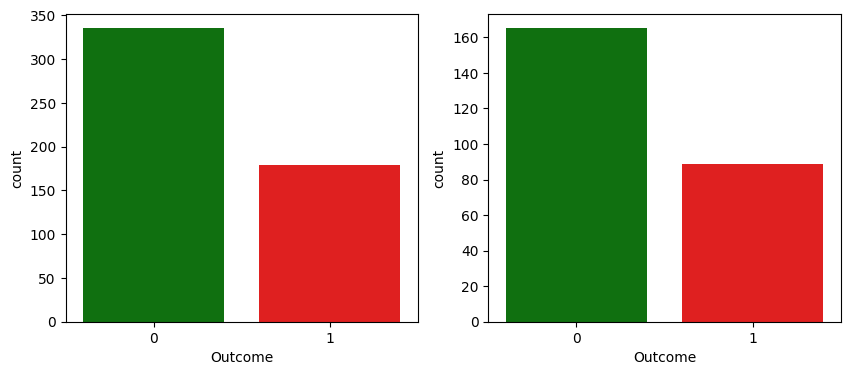

In [20]:
ig, axes = plt.subplots(1,2, figsize=(10, 4))
fig.suptitle("Representation of target variable: Train (left) vs. Test (right) data set")
sns.countplot(x=df_train.Outcome, ax=axes[0], palette={'0': 'green', '1': 'red'});
sns.countplot(x=df_test.Outcome, ax=axes[1], palette={'0': 'green', '1': 'red'});

# Exploration and Cleaning

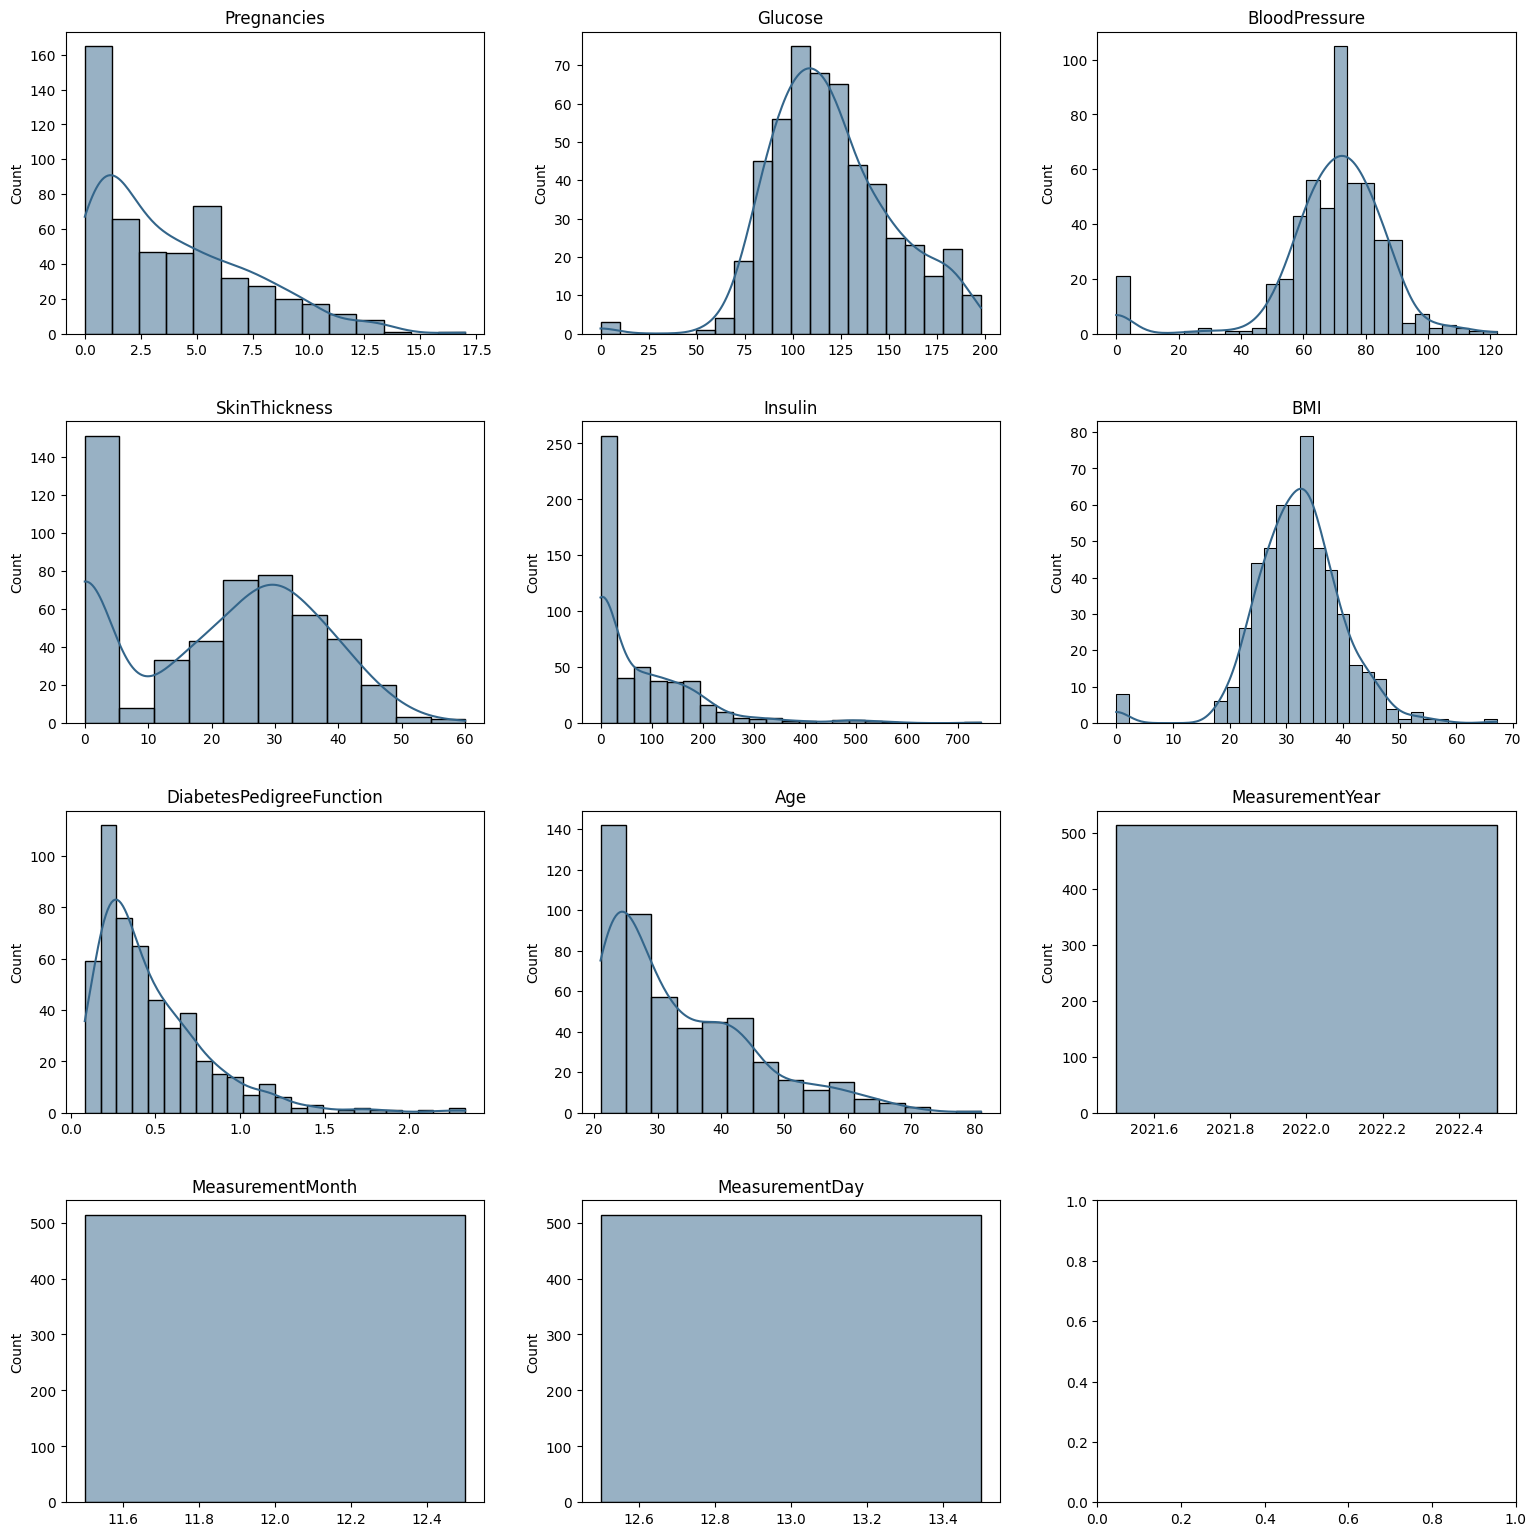

In [24]:
features = df_train.columns.tolist()
features.remove('Outcome')

fig,ax = plt.subplots(4,3,figsize=(16,16)) # Changed from 3,3 to 4,3 and adjusted figsize
count = 0
for item in features:
    sns.histplot(df_train[item], kde=True, ax=ax[int(count/3)][count%3], color='#33658A').set(title=item, xlabel='')
    count += 1
# ax.flat[-1].set_visible(False) # Removed as we might need all subplots now
fig.tight_layout(pad=3)

# Analysis of Missing Values (== 0)

In [26]:
# Replace zeros with np.nan
def replace_zeros(df, feature):
    df[feature] = df[feature].replace(0, np.nan)
    return df

columns_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in columns_with_zeros:
    df_train = replace_zeros(df_train, col)

In [27]:
# Check for missing data
df_train.isnull().sum()

,0
Pregnancies,0
Glucose,3
BloodPressure,21
SkinThickness,151
Insulin,249
BMI,8
DiabetesPedigreeFunction,0
Age,0
MeasurementYear,0
MeasurementMonth,0


In [28]:
print(df_train.query("BMI.isnull() & BloodPressure.isnull()").shape[0])
index_list = df_train.query("BMI.isnull() & BloodPressure.isnull()").index.tolist()
df_train.query("BMI.isnull() & BloodPressure.isnull()")

5


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,MeasurementYear,MeasurementMonth,MeasurementDay,Outcome
60,2,84.0,NaN,NaN,NaN,NaN,0.304,21,2022,12,13,0
426,0,94.0,NaN,NaN,NaN,NaN,0.256,25,2022,12,13,0
522,6,114.0,NaN,NaN,NaN,NaN,0.189,26,2022,12,13,0
49,7,105.0,NaN,NaN,NaN,NaN,0.305,24,2022,12,13,0
706,10,115.0,NaN,NaN,NaN,NaN,0.261,30,2022,12,13,1
